# Charger le datraframe #

In [3]:
import pandas as pd
import unicodedata
df = pd.read_csv(
    "ncr_ride_bookings.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)


# Supprime les espaces au début et à la fin des noms de colonnes #

In [4]:
df.columns = df.columns.str.strip()

# Supprimer les doublons #

In [5]:
df = df.drop_duplicates()

# Supprimer les espaces en début de chaque valeur #

In [6]:
# Sélection des colonnes de type chaîne
string_cols = df.select_dtypes(include="object").columns

# Suppression des espaces en début et fin de chaque valeur
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip())
# remplacer les espaces multiples par un seul
df[string_cols] = df[string_cols].apply(
    lambda col: col.str.replace(r"\s+", " ", regex=True).str.strip()
)
# vérifier que les espaces ont bien été supprimés
print(df.columns.tolist())

for col in string_cols:
    print(df[col].head())

C:\Users\yannb\AppData\Local\Temp\ipykernel_11884\3566595447.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include="object").columns


['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']
0    2024-03-23
1    2024-11-29
2    2024-08-23
3    2024-10-21
4    2024-09-16
Name: Date, dtype: str
0    12:29:38
1    18:01:39
2    08:56:10
3    17:17:25
4    22:08:00
Name: Time, dtype: str
0    "CNR5884300"
1    "CNR1326809"
2    "CNR8494506"
3    "CNR8906825"
4    "CNR1950162"
Name: Booking ID, dtype: str
0    No Driver Found
1         Incomplete
2          Completed
3          Completed
4          Completed
Name: Booking Status, dtype: str
0    "CID1982111"
1    "CID4604802"
2    "CID9202816"
3    "CID2610914"
4    "CID9933542"
Name: Customer ID, dtype: str
0            eBike
1    

# Uniformiser les booking id #

In [7]:
id_cols = ["Booking ID", "Customer ID"]

for col in id_cols:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()

# Uniformiser les dates #

In [8]:
import re
from datetime import datetime

def uniformiser_date(date):

    if not isinstance(date, str):
        return None

    date = date.strip()

    # Uniformiser les séparateurs
    date = re.sub(r"\s*-\s*", "-", date)
    date = re.sub(r"\s+", "-", date)
    date = date.replace("/", "-")

    formats = [
        "%Y-%m-%d",   # 1995-02-10
        "%m-%d-%Y",   # 09-21-1972
        "%d-%m-%Y",   # 23-07-2008
        "%d-%b-%y",   # 22-Feb-04
        "%d-%B-%Y",   # 22-February-2004
        "%d-%b-%Y",   # 22-Feb-2004
    ]

    for fmt in formats:
        try:
            d = datetime.strptime(date, fmt)
            return d.strftime("%Y/%m/%d")
        except ValueError:
            pass

    return None

df["Date"] = df["Date"].apply(uniformiser_date)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [ ]:
df.describe()

# Distribution de la valeur des réservations #

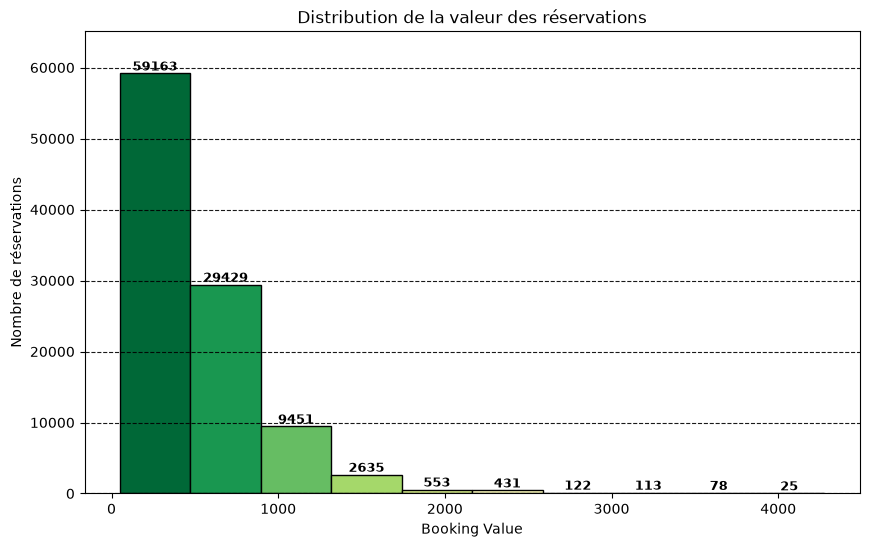

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Booking Value"].dropna(),
    bins=10,
    edgecolor="black"
)

# Normalisation des valeurs des classes
norm = mcolors.Normalize(vmin=bins.min(), vmax=bins.max())
cmap = plt.colormaps["RdYlGn_r"]  # Vert → Jaune → Rouge

# Attribution des couleurs
for i, patch in enumerate(patches):
    patch.set_facecolor(cmap(norm(bins[i])))

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # N'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.title("Distribution de la valeur des réservations")
plt.xlabel("Booking Value")
plt.ylabel("Nombre de réservations")
plt.grid(axis="y", linestyle="--", alpha=0.9, color="black")

# Laisse un peu d'espace au-dessus des barres pour les étiquettes
plt.ylim(0, max(n) * 1.1)

plt.show()

# Distribution de la distance en fonction du nombre de courses #

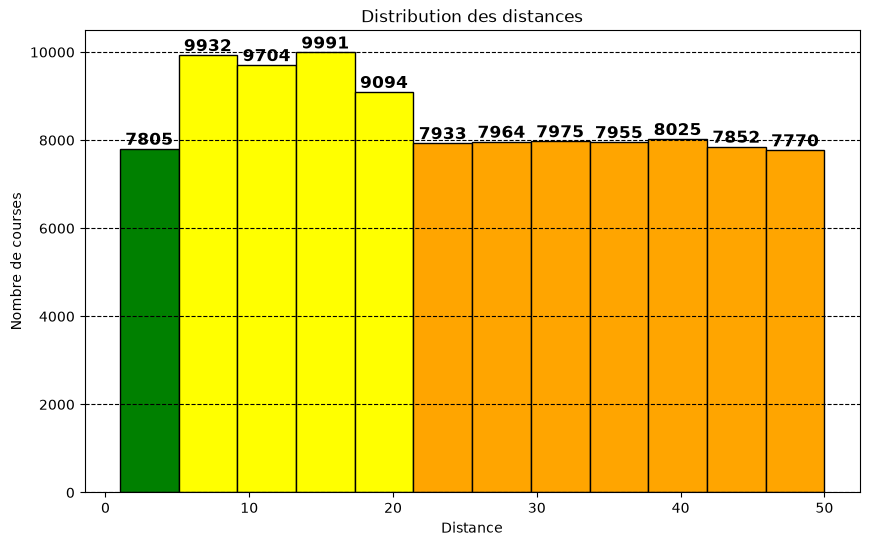

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Ride Distance"].dropna(),
    bins=12,
    edgecolor="black"

)

# Coloration selon la distance
for i, patch in enumerate(patches):
    if bins[i] < 5:
        patch.set_facecolor("green")
    elif bins[i] < 20:
        patch.set_facecolor("yellow")
    elif bins[i] < 50:
        patch.set_facecolor("orange")
    else:
        patch.set_facecolor("red")

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # n'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight= "bold"
            
        )

        

plt.title("Distribution des distances")
plt.xlabel("Distance")
plt.ylabel("Nombre de courses")
plt.grid(axis="y", linestyle="--", alpha=1.0, color="black")

plt.show()

# Répartitions des réservations #

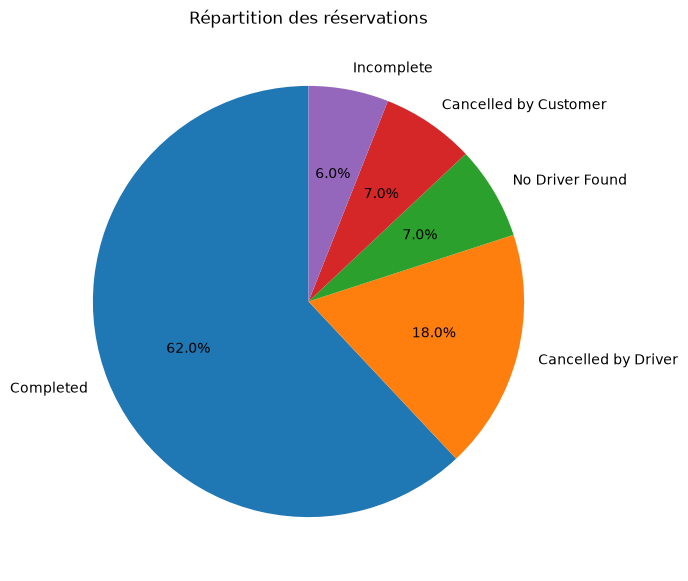

In [ ]:
status = df["Booking Status"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(status.values,
        labels=status.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Répartition des réservations")

plt.show()

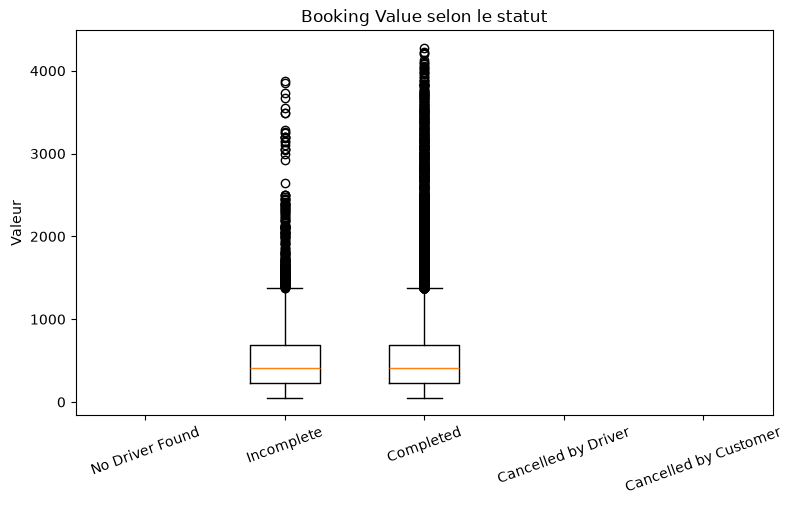

In [ ]:
data = []
labels= []
for statut in df["Booking Status"].unique():
    data.append(
        df[df["Booking Status"] == statut]["Booking Value"].dropna()
    )

plt.figure(figsize=(9,5))

plt.boxplot(data,
            tick_labels=df["Booking Status"].unique())

plt.xticks(rotation=20)

plt.title("Booking Value selon le statut")

plt.ylabel("Valeur")

plt.show()

# Répartition des status des réservations #

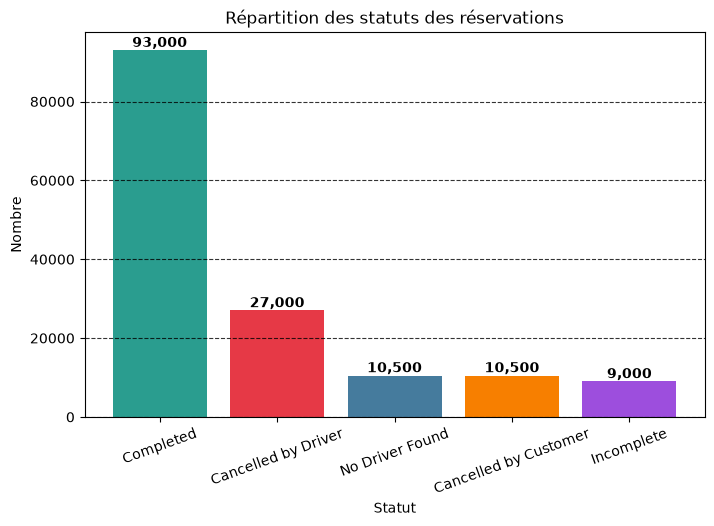

In [ ]:
status = df["Booking Status"].value_counts()

couleurs = {
    "Completed": "#2A9D8F",
    "Cancelled by Driver": "#E63946",
    "Cancelled by Customer": "#F77F00",
    "No Driver Found": "#457B9D",
    "Incomplete": "#9D4EDD"
}

bar_colors = [couleurs[s] for s in status.index]

plt.figure(figsize=(8,5))

bars = plt.bar(status.index,
               status.values,
               color=bar_colors)

plt.title("Répartition des statuts des réservations")
plt.xlabel("Statut")
plt.ylabel("Nombre")

plt.xticks(rotation=20)

# Affichage des valeurs sur les barres
for bar in bars:
    hauteur = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        hauteur,
        f"{int(hauteur):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.8, color="black")

plt.show()

# Répartition des notes des chauffeurs #

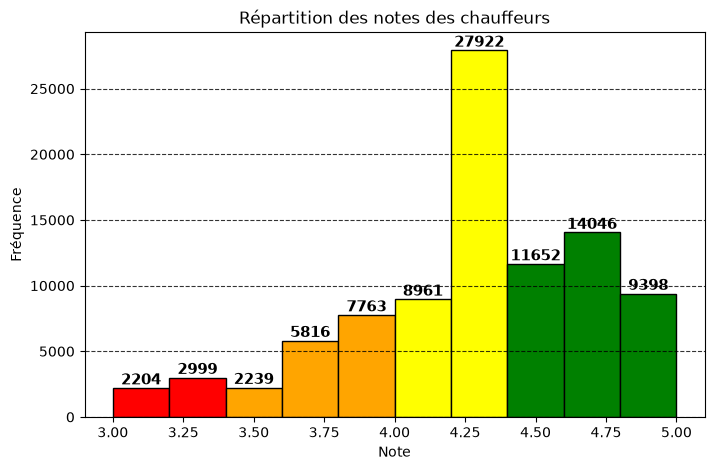

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Driver Ratings"].dropna(),
    bins=10,
    edgecolor="black"
)

# Couleur des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")      # Mauvaise note
    elif centre < 4.0:
        patches[i].set_facecolor("orange")   # Note moyenne
    elif centre < 4.5:
        patches[i].set_facecolor("yellow")   # Bonne note
    else:
        patches[i].set_facecolor("green")    # Excellente note

plt.title("Répartition des notes des chauffeurs")
plt.xlabel("Note")
plt.ylabel("Fréquence")

plt.grid(axis="y",
         linestyle="--",
         alpha=0.8,
         color="black")
for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

plt.show()

# Répartition des notes des clients #

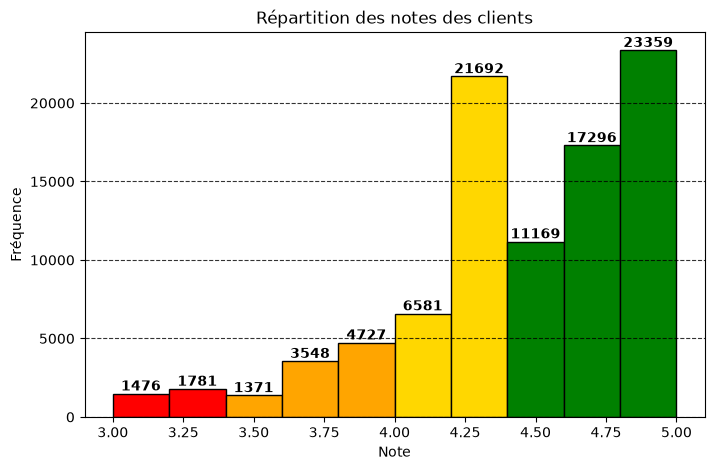

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

n, bins, patches = plt.hist(
    df["Customer Rating"].dropna(),
    bins=10,
    edgecolor="black"
)

# Coloration des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")
    elif centre < 4.0:
        patches[i].set_facecolor("orange")
    elif centre < 4.5:
        patches[i].set_facecolor("gold")
    else:
        patches[i].set_facecolor("green")

plt.title("Répartition des notes des clients")
plt.xlabel("Note")
plt.ylabel("Fréquence")
plt.grid(axis="y", linestyle="--", alpha=0.8, color ="black")

for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )
plt.show()

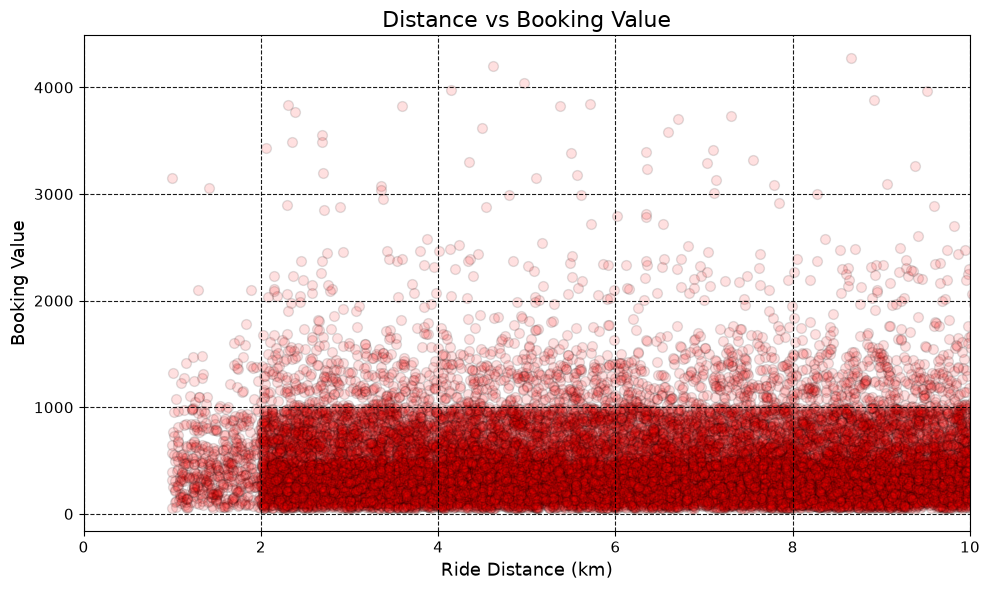

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Ride Distance"],
    df["Booking Value"],
    alpha=0.12,
    color="red",
    s=50,               # Taille des points
    edgecolors="black", # Contour des points
    linewidth=1
)

plt.title("Distance vs Booking Value", fontsize=16)
plt.xlabel("Ride Distance (km)", fontsize=13)
plt.ylabel("Booking Value", fontsize=13)

# Taille des graduations
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Afficher uniquement les distances entre 0 et 10
plt.xlim(0, 10)

plt.grid(True, linestyle="--", alpha=0.9, color= "black")

plt.tight_layout()
plt.show()

# Temps d'attente moyen pour l'arrivée d'un véhicule d'un conducteur #

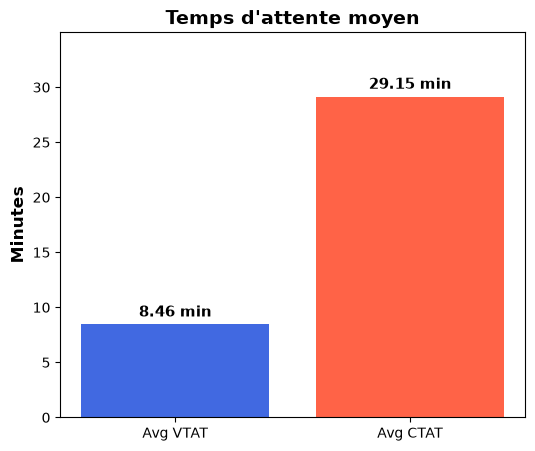

In [ ]:
import matplotlib.pyplot as plt

moyennes = [
    df["Avg VTAT"].mean(),
    df["Avg CTAT"].mean()
]

labels = ["Avg VTAT", "Avg CTAT"]

plt.figure(figsize=(6,5))

bars = plt.bar(
    labels,
    moyennes,
    color=["royalblue", "tomato"]
)

# Affichage des valeurs au-dessus des barres
plt.bar_label(
    bars,
    fmt="%.2f min",      # 2 décimales + unité
    fontsize=11,
    fontweight="bold",
    padding=3
)

plt.ylabel("Minutes", fontsize=12, fontweight="bold")
plt.title("Temps d'attente moyen", fontsize=14, fontweight="bold")
plt.ylim(0, max(moyennes) * 1.2)

plt.show()

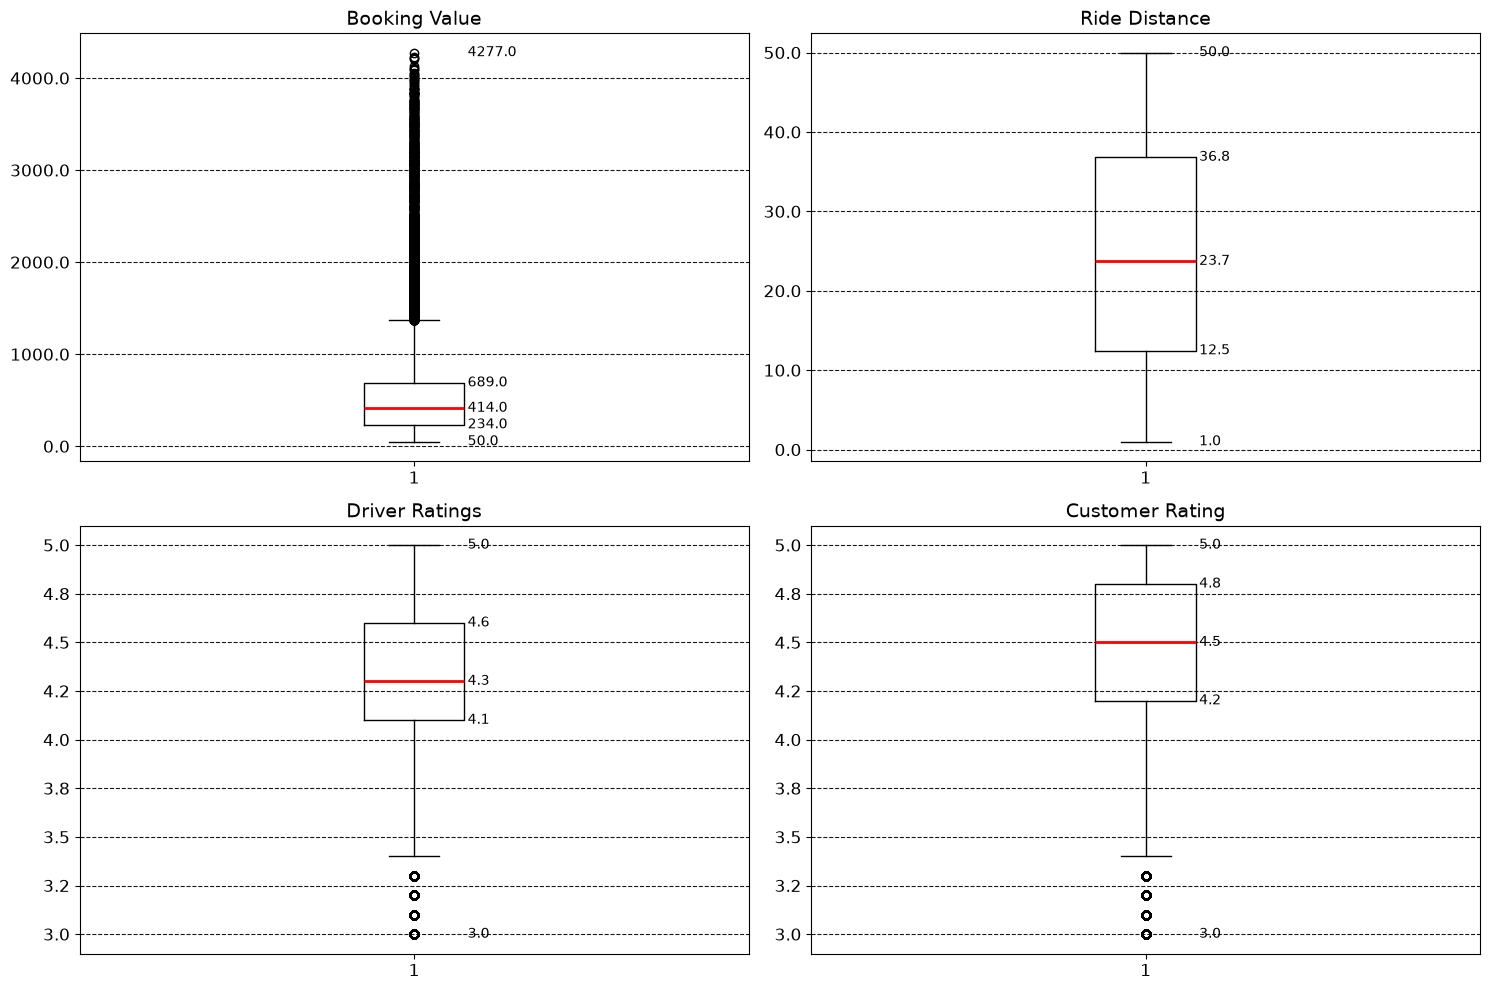

In [ ]:
import numpy as np
from matplotlib.ticker import FormatStrFormatter

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

colonnes = [
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

for axes, colonne in zip(ax.flat, colonnes):
    valeurs = df[colonne].dropna()

    axes.boxplot(
        valeurs,
        medianprops={"color": "red", "linewidth": 2}
    )

    axes.set_title(colonne, fontsize=14)
    axes.tick_params(labelsize=12)
    axes.grid(axis="y", linestyle="--", alpha=0.9, color="black")
    axes.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    # Calcul des statistiques
    mini = valeurs.min()
    q1 = valeurs.quantile(0.25)
    med = valeurs.median()
    q3 = valeurs.quantile(0.75)
    maxi = valeurs.max()

    # Affichage des valeurs
    for y in [mini, q1, med, q3, maxi]:
        axes.text(
            1.08, y,
            f"{y:.1f}",
            va="center",
            fontsize=10
        )

plt.tight_layout()
plt.show()